

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>


In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


rest_data = pd.read_csv('/datasets/rest_data_us_upd.csv')

rest_data.columns

Index(['id', 'object_name', 'address', 'chain', 'object_type', 'number'], dtype='object')

In [35]:
rest_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [36]:
rest_data.isna().sum()

id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

In [37]:
rest_data.duplicated().sum()

0

In [38]:
rest_data.describe(include='all')


,id,object_name,address,chain,object_type,number
count,9651.000000,9651,9651,9648,9651,9651.000000
unique,NaN,8672,8512,2,6,NaN
top,NaN,THE COFFEE BEAN & TEA LEAF,3607 TROUSDALE PKWY,False,Restaurant,NaN
freq,NaN,47,11,5972,7255,NaN
mean,16611.000000,NaN,NaN,NaN,NaN,43.695161
std,2786.148058,NaN,NaN,NaN,NaN,47.622874
min,11786.000000,NaN,NaN,NaN,NaN,1.000000
25%,14198.500000,NaN,NaN,NaN,NaN,14.000000
50%,16611.000000,NaN,NaN,NaN,NaN,27.000000
75%,19023.500000,NaN,NaN,NaN,NaN,46.000000


In [39]:
rest_data = rest_data.dropna(subset=['chain'])

In [40]:
rest_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9648 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9648 non-null   int64 
 1   object_name  9648 non-null   object
 2   address      9648 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9648 non-null   object
 5   number       9648 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 527.6+ KB


In [41]:
rest_data['object_type'].value_counts()

Restaurant    7253
Fast Food     1066
Cafe           435
Pizza          319
Bar            292
Bakery         283
Name: object_type, dtype: int64

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>




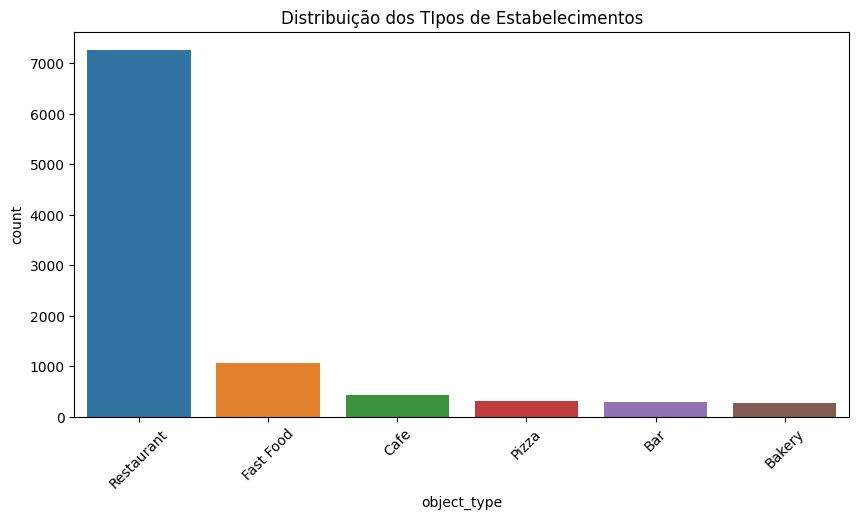

In [42]:
plt.figure(figsize=(10, 5))
sns.countplot(data=rest_data, x= 'object_type', order=rest_data['object_type'].value_counts().index)
plt.title('Distribuição dos TIpos de Estabelecimentos')
plt.xticks(rotation=45)
plt.show()

Aqui podemos verificar a distribuição dos tipos de estabelecimentos, os estabelecimentos denominados restaurantes são a grande maioria em nossa base de dados, isso pode estar ligado a palavra "Restaurante" ser abrangente, um restaurante pode ser diferentes tipos de estabelecimentos que servem refeição, ja um fest food, um café ou uma pizzaria são conhecidos por um tipo especifico de refeição principal. 


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tipos de estabelecimento foram investigados com presença adequada de visualização e conclusão!
</div>

In [43]:
rest_data['chain'].value_counts()

False    5972
True     3676
Name: chain, dtype: int64

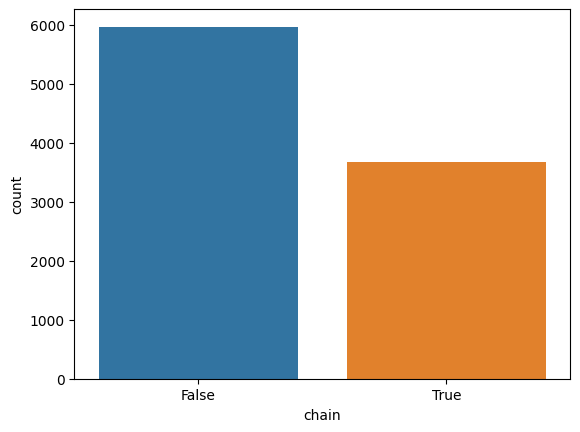

In [44]:
sns.countplot(data=rest_data, x='chain')
plt.show()

gráfico acima mostra a proporção entre estabelecimentos que pertencem a uma rede (`True`) e aqueles que operam de forma independente (`False`). Observamos que a maior parte dos estabelecimentos **não pertence a uma rede**, totalizando 5.972 unidades, enquanto 3.676 fazem parte de redes.

Essa diferença indica que o mercado local é predominantemente composto por estabelecimentos independentes, que representam a maioria das operações. Redes também estão presentes, mas em menor quantidade, sugerindo que o setor possui uma forte base de negócios individuais e não necessariamente concentrado em grandes franquias.

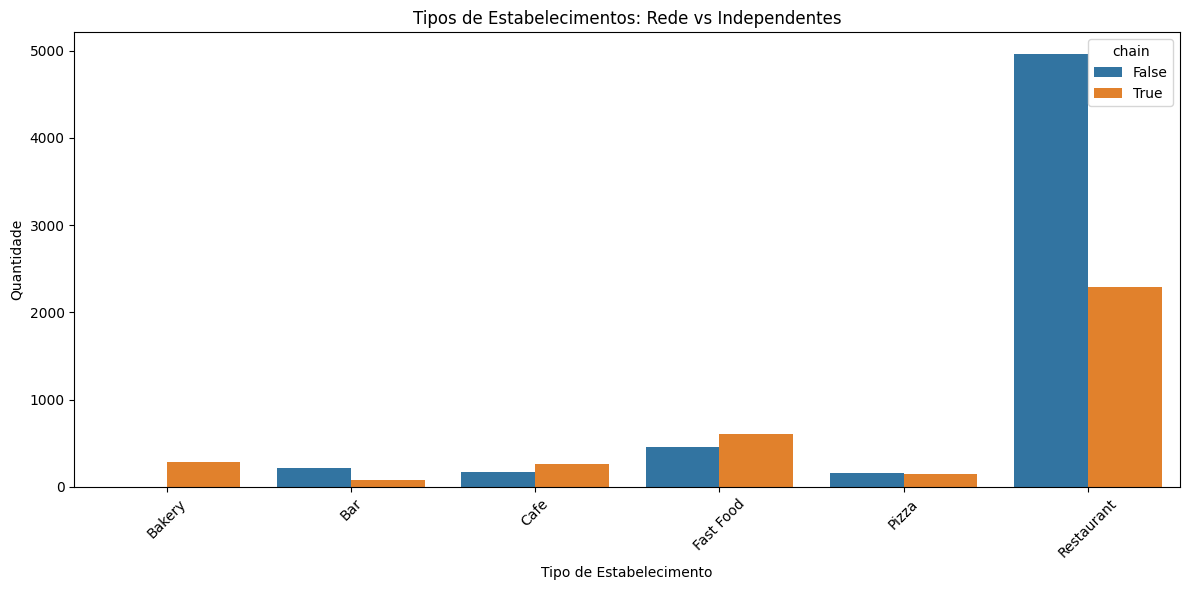

In [45]:


crosstab = pd.crosstab(rest_data['object_type'], rest_data['chain'])


crosstab_reset = crosstab.reset_index().melt(id_vars='object_type',
                                             var_name='chain',
                                             value_name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=crosstab_reset, x='object_type', y='count', hue='chain')
plt.title('Tipos de Estabelecimentos: Rede vs Independentes')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [46]:
print(crosstab)

chain        False  True 
object_type              
Bakery           0    283
Bar            215     77
Cafe           169    266
Fast Food      461    605
Pizza          166    153
Restaurant    4961   2292


A tabela cruzando `object_type` e `chain` mostra como cada tipo de estabelecimento se distribui entre negócios independentes (`False`) e redes (`True`). A análise revela padrões importantes:

- **Bakery**: todas as 283 unidades pertencem a redes. Isso indica um setor altamente padronizado e dominado por marcas estabelecidas.
- **Bar**: 215 independentes contra 77 de rede. É um mercado predominantemente local, onde negócios individuais são mais comuns.
- **Cafe**: 169 independentes e 266 de rede. Há presença forte nos dois cenários, sugerindo um mercado consolidado e competitivo.
- **Fast Food**: 461 independentes e 605 de rede. O setor é dominado por redes, o que faz sentido dada a natureza padronizada e escalável desse modelo de negócio.
- **Pizza**: 166 independentes e 153 de rede. É um mercado tradicional e equilibrado, com leve predominância de estabelecimentos independentes, possivelmente por ser um nicho mais artesanal e associado a culinária típica.
- **Restaurant**: 4.961 independentes e 2.292 de rede. A grande maioria é independente, o que é esperado, já que “restaurant” é a categoria mais ampla e engloba diversos tipos de estabelecimentos únicos.

**Conclusão geral:**  
Os tipos mais característicos de redes são **Bakery**, **Fast Food** e **Cafe**, enquanto **Bar**, **Pizza** e principalmente **Restaurant** são dominados por estabelecimentos independentes.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Redes investigadas tanto no agregado quanto na quebra por tipo de estabelecimento.
</div>


In [33]:

rest_data['rede_nome'] = rest_data['object_name'].str.replace(r'#.*', '', regex=True).str.strip()


chain_data = rest_data[rest_data['chain'] == True]


chain_analysis = chain_data.groupby('rede_nome').agg({
    'id': 'count',        
    'number': 'mean'      
}).rename(columns={
    'id': 'quantidade_estabelecimentos',
    'number': 'media_assentos'
}).sort_values(by='quantidade_estabelecimentos', ascending=False)


chain_analysis.head(10)

,quantidade_estabelecimentos,media_assentos
rede_nome,,
SUBWAY,113,16.592920
STARBUCKS COFFEE,87,24.850575
MCDONALD'S,81,94.308642
JACK IN THE BOX,53,65.981132
THE COFFEE BEAN & TEA LEAF,51,26.235294
EL POLLO LOCO,35,66.914286
BURGER KING,35,83.571429
PIZZA HUT,30,14.633333
STARBUCKS,30,33.633333


Texto resumido para o Jupyter
As redes são definidas como empresas que operam um ou mais estabelecimentos, independentemente do tamanho ou do número de assentos. Por isso, mesmo marcas com apenas uma unidade no dataset continuam classificadas como rede. Após padronizar os nomes (removendo identificadores como “#123”), agrupamos as redes para analisar quantas unidades cada uma possui e a média de assentos por estabelecimento. Essa abordagem permite entender o comportamento das redes no mercado sem excluir informações importantes.


In [47]:
rest_data['number'].describe()

count    9648.000000
mean       43.703566
std        47.627252
min         1.000000
25%        14.000000
50%        27.000000
75%        46.000000
max       229.000000
Name: number, dtype: float64

A distribuição do número de assentos apresenta um mínimo de 1, o que é comum em estabelecimentos muito pequenos, como quiosques ou pontos de venda sem área de refeição. A mediana de 27 assentos indica que metade dos estabelecimentos é relativamente compacta, enquanto a média de 43 sugere a presença de alguns restaurantes maiores que elevam o valor médio. O máximo de 229 assentos confirma a existência de estabelecimentos de grande porte, criando uma cauda longa na distribuição.

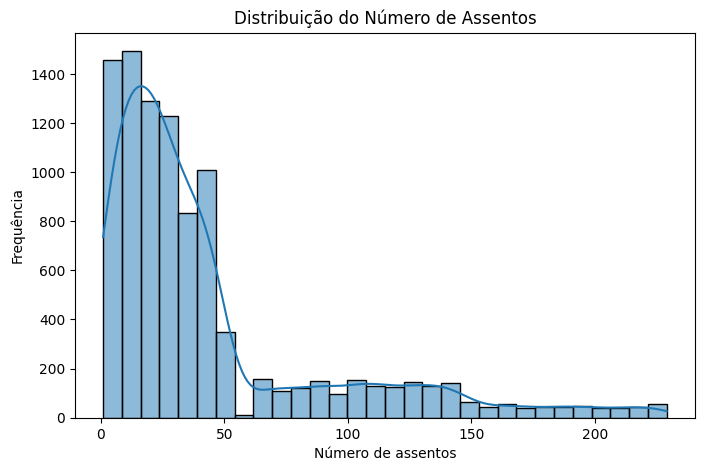

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(rest_data['number'], bins=30, kde=True)
plt.title('Distribuição do Número de Assentos')
plt.xlabel('Número de assentos')
plt.ylabel('Frequência')
plt.show()

A distribuição do número de assentos apresenta uma cauda longa à direita, indicando que a maior parte dos estabelecimentos possui entre **0 e 50 assentos**, enquanto valores acima de 50 tornam‑se progressivamente menos frequentes. Isso revela uma predominância de estabelecimentos compactos.

Esse padrão pode refletir tendências atuais do setor, como o crescimento de modelos de negócio focados em **take-away**, **drive-thru** e **entregas por aplicativos**, que exigem menos espaço físico. Além disso, muitos estabelecimentos de fast-food e cafés operam com áreas reduzidas, reforçando essa concentração nos valores mais baixos.


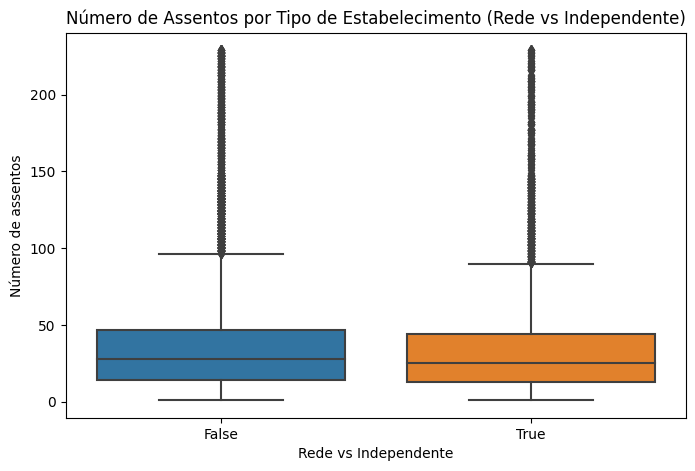

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(data=rest_data, x='chain', y='number')
plt.title('Número de Assentos por Tipo de Estabelecimento (Rede vs Independente)')
plt.xlabel('Rede vs Independente')
plt.ylabel('Número de assentos')
plt.show()

O boxplot mostra que a distribuição do número de assentos é muito semelhante entre estabelecimentos que pertencem a uma rede (`True`) e aqueles que operam de forma independente (`False`). As medianas são praticamente iguais, e a amplitude interquartil também é bastante próxima.

A diferença entre os dois grupos é mínima e quase imperceptível, indicando que o fato de um estabelecimento ser ou não parte de uma rede **não influencia significativamente** sua capacidade de assentos. Ambos os grupos apresentam muitos outliers acima do limite superior, representando restaurantes maiores, mas isso ocorre de forma equilibrada nos dois casos.


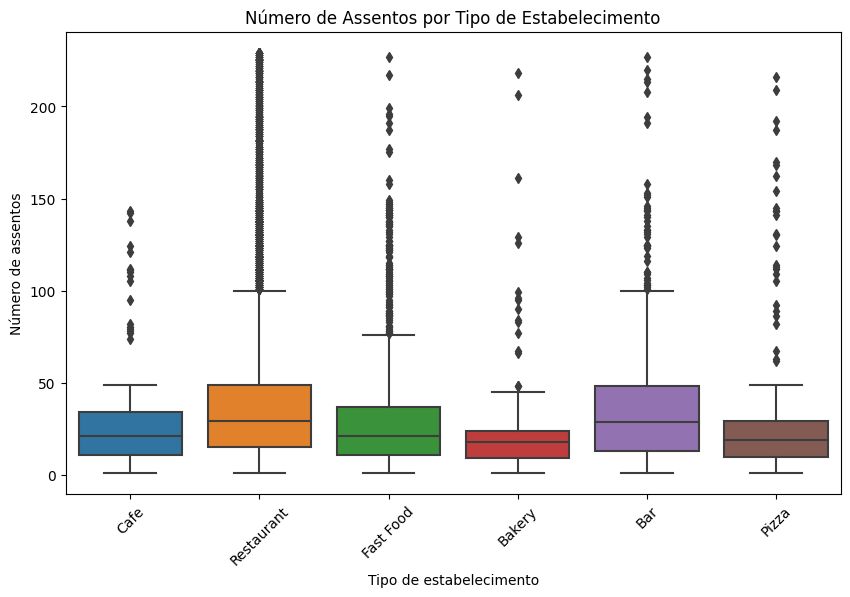

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=rest_data, x='object_type', y='number')
plt.title('Número de Assentos por Tipo de Estabelecimento')
plt.xlabel('Tipo de estabelecimento')
plt.ylabel('Número de assentos')
plt.xticks(rotation=45)
plt.show()


O boxplot mostra que os tipos *Restaurant*, *Fast Food* e *Bar* apresentam, em geral, os maiores números de assentos, o que faz sentido considerando que costumam atender um fluxo maior de clientes. No entanto, apesar dessas diferenças visuais, as medianas entre os tipos são relativamente próximas, indicando que a maior parte dos estabelecimentos — independentemente da categoria — opera com capacidades semelhantes.

O grupo *Restaurant* apresenta a maior quantidade de valores atípicos (outliers), o que é esperado, já que essa categoria é ampla e inclui desde pequenos restaurantes familiares até grandes casas com centenas de lugares. Essa variedade amplia bastante a dispersão dos dados.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Comparativo da volumetria de assentos entre redes e não redes foi realizada de forma elucidativa.
</div>


In [17]:
rest_data['street'] = rest_data['address'].str.extract(r'\d+\s+(.*)')

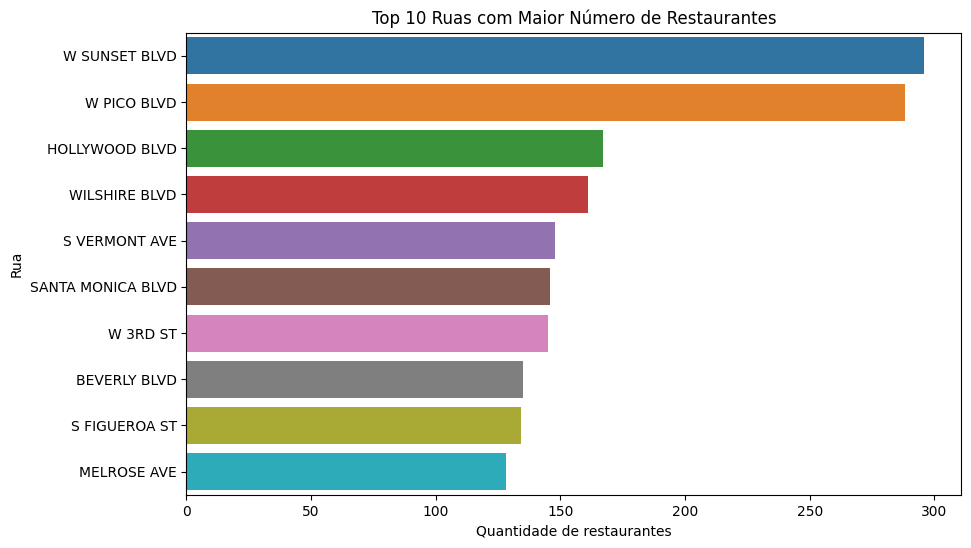

In [18]:
top_10_streets = rest_data['street'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_10_streets.values, y=top_10_streets.index)
plt.title('Top 10 Ruas com Maior Número de Restaurantes')
plt.xlabel('Quantidade de restaurantes')
plt.ylabel('Rua')
plt.show()

As ruas W Sunset Blvd e W Pico Blvd concentram o maior número de restaurantes, com valores significativamente superiores às demais — praticamente o dobro das outras ruas do ranking. As demais vias apresentam quantidades muito próximas entre si, formando um grupo relativamente homogêneo. Esse padrão sugere que Sunset e Pico são importantes corredores gastronômicos, enquanto as outras ruas mantêm uma distribuição mais equilibrada de estabelecimentos.


In [21]:

single_restaurant_streets = rest_data['street'].value_counts()
single_restaurant_streets = (single_restaurant_streets == 1).sum()
print('Ruas com apenas um 
restaurante:', single_restaurant_streets)

Ruas com apenas um restaurante: 2442


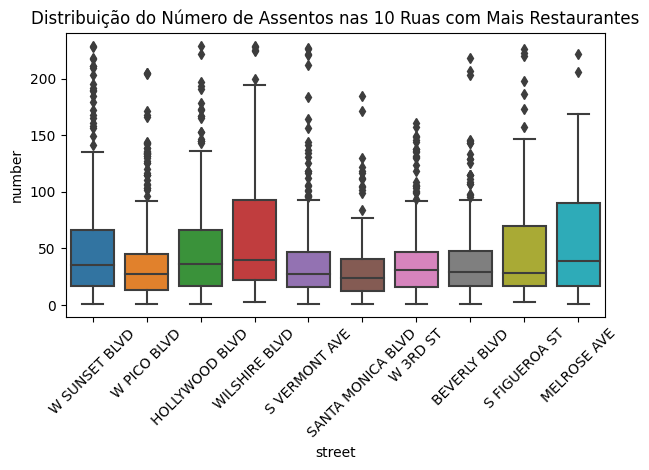

In [30]:

top_10_streets = rest_data['street'].value_counts().head(10).index
filtered_data = rest_data[rest_data['street'].isin(top_10_streets)]



sns.boxplot(data=filtered_data, x = 'street', y = 'number', order= top_10_streets)
plt.xticks(rotation=45)
plt.title('Distribuição do Número de Assentos nas 10 Ruas com Mais Restaurantes')
plt.xlabel('street')
plt.ylabel('number')
plt.tight_layout()


Ao analisar a distribuição do número de assentos nas 10 ruas com mais restaurantes, observa-se que há bastante variação entre elas. Algumas ruas, como Wilshire Blvd e Melrose Ave, apresentam restaurantes com maior capacidade média e maior dispersão no número de assentos, sugerindo a presença de estabelecimentos maiores. Já ruas como W 3rd St, Beverly Blvd e S Figueroa St tendem a ter capacidades mais concentradas em faixas menores, indicando restaurantes de porte mais reduzido. No geral, as principais vias combinam tanto restaurantes pequenos quanto grandes, refletindo uma oferta diversificada de perfis de estabelecimentos.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As manipulações solicitadas relativas ao endereço e análises correspondentes foram realizadas! Gráficos e conclusão estão presentes conforme solicitado.
</div>



Esta etapa final, reunimos os principais achados obtidos ao longo da exploração dos dados. A análise permitiu identificar padrões relevantes sobre a distribuição de restaurantes, suas localizações e características estruturais, como o número de assentos disponíveis.


A análise revelou que algumas ruas concentram um número significativamente maior de restaurantes, indicando regiões com maior fluxo comercial e potencial competitivo mais elevado. Além disso, a variação no número de assentos entre as ruas sugere diferenças no perfil dos estabelecimentos: algumas áreas apresentam restaurantes maiores e mais estruturados, enquanto outras concentram negócios menores e mais simples. Esses padrões ajudam a identificar zonas mais adequadas para diferentes tipos de investimento no setor de alimentação.



Com base nos padrões observados, algumas recomendações podem orientar a escolha do local ideal para a nova cafeteria:

- Priorizar ruas com grande fluxo de restaurantes, como W Sunset Blvd e W Pico Blvd, que apresentam maior movimento e potencial de atração de clientes.
- Considerar ruas com restaurantes menores e menos dispersão no número de assentos, pois podem indicar menor concorrência direta com estabelecimentos de grande porte.
- Avaliar regiões onde há equilíbrio entre quantidade de restaurantes e diversidade de perfis, permitindo que a cafeteria se destaque sem enfrentar saturação.
- Investigar presencialmente as áreas identificadas para validar fatores não presentes nos dados, como fluxo de pedestres, acessibilidade e presença de escritórios ou residências.



A análise mostra que o mercado gastronômico da cidade é dominado por estabelecimentos independentes e de pequeno porte, com grande concentração de restaurantes em algumas avenidas específicas. No entanto, a existência de 2.442 ruas com apenas um restaurante revela amplas oportunidades em áreas com baixa concorrência direta.

Recomenda-se priorizar regiões menos saturadas, onde a cafeteria possa se destacar e atrair o público local. Além disso, optar por um porte compatível com o padrão da cidade — estabelecimentos menores e acolhedores — tende a alinhar melhor a proposta ao comportamento do mercado.




A apresentação final do projeto pode ser acessada no link abaixo:

**Presentation:** <https://1drv.ms/b/c/88720a3b27fe9d91/IQBqQ6Rm0ZEHQp1Yy0JLuw62AbooUNmYHE17rxkQ_jCrhYk?e=qfLsMR>

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Apresentação e conclusão presentes.
</div>

